## Photo filtering example — Task 3.2

In [22]:
import sys

print("Python:", sys.executable)
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\git\visual-brand-audit\src')

Python: F:\V_Tech Semesters\MS Thesis\Jupyter_MS\venv\Python_3120_modgen3d\Scripts\python.exe


In [23]:
from dataclasses import asdict
from math import ceil

import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
from skimage import data

from brandlens.preprocessing.photo_filter import FilterSettings, filter_photo

settings = FilterSettings()
# settings = FilterSettings(min_short_side=12, max_aspect_ratio=5.0)
print("Settings:", asdict(settings))


Settings: {'min_short_side': 64, 'max_aspect_ratio': 5.0}


# 1. Load real images
Source: scikit-image sample data.

This notebook loads images through the public API and does not bundle image files. The labels below describe content for this demonstration; they are not supplied photo-filter benchmark labels.

In [17]:
samples = [
    {"name": "Astronaut", "kind": "photograph", "image": Image.fromarray(data.astronaut())},
    {"name": "Coffee", "kind": "photograph", "image": Image.fromarray(data.coffee())},
    {"name": "Chelsea", "kind": "photograph", "image": Image.fromarray(data.chelsea())},
    {"name": "Camera", "kind": "photograph", "image": Image.fromarray(data.camera())},
    {"name": "Scikit-image logo", "kind": "graphic", "image": Image.fromarray(data.logo())},
]
print("Loaded", len(samples), "original samples.")

coffee = samples[1]["image"]
logo = samples[4]["image"]
small_photo = coffee.copy()
small_photo.thumbnail((48, 48))
small_logo = logo.copy()
small_logo.thumbnail((32, 32))

# Crop a real photograph to a wide strip; do not stretch its content.
wide_photo = coffee.crop((0, 100, coffee.width, 180))

samples.extend([
    {"name": "Small photograph", "kind": "photograph variant", "image": small_photo},
    {"name": "Wide photo crop", "kind": "photograph variant", "image": wide_photo},
    {"name": "Small logo", "kind": "graphic variant", "image": small_logo},
])


Loaded 5 original samples.


In [18]:
def inspect_samples(samples, settings):
    """Run the imported filter and return measurements for display."""
    results = []
    for sample in samples:
        image = sample["image"]
        filtered = filter_photo(image, settings)
        width, height = image.size
        results.append({
            "name": sample["name"],
            "kind": sample["kind"],
            "width": width,
            "height": height,
            "short_side": min(width, height),
            "aspect_ratio": max(width, height) / min(width, height),
            "keep": filtered is not None,
        })
        if filtered is not None:
            assert filtered is image, "Accepted output should be the original object."
    return results

results = inspect_samples(samples, settings)
print(f"{'Image':<23} {'Size':<13} {'Ratio':>7}  {'Decision'}")
for row in results:
    size = f"{row['width']} x {row['height']}"
    print(f"{row['name']:<23} {size:<13} {row['aspect_ratio']:>7.2f}  "
          f"{'KEEP' if row['keep'] else 'EXCLUDE'}")


Image                   Size            Ratio  Decision
Astronaut               512 x 512        1.00  KEEP
Coffee                  600 x 400        1.50  KEEP
Chelsea                 451 x 300        1.50  KEEP
Camera                  512 x 512        1.00  KEEP
Scikit-image logo       500 x 500        1.00  KEEP
Small photograph        48 x 32          1.50  EXCLUDE
Wide photo crop         600 x 80         7.50  EXCLUDE
Small logo              32 x 32          1.00  EXCLUDE


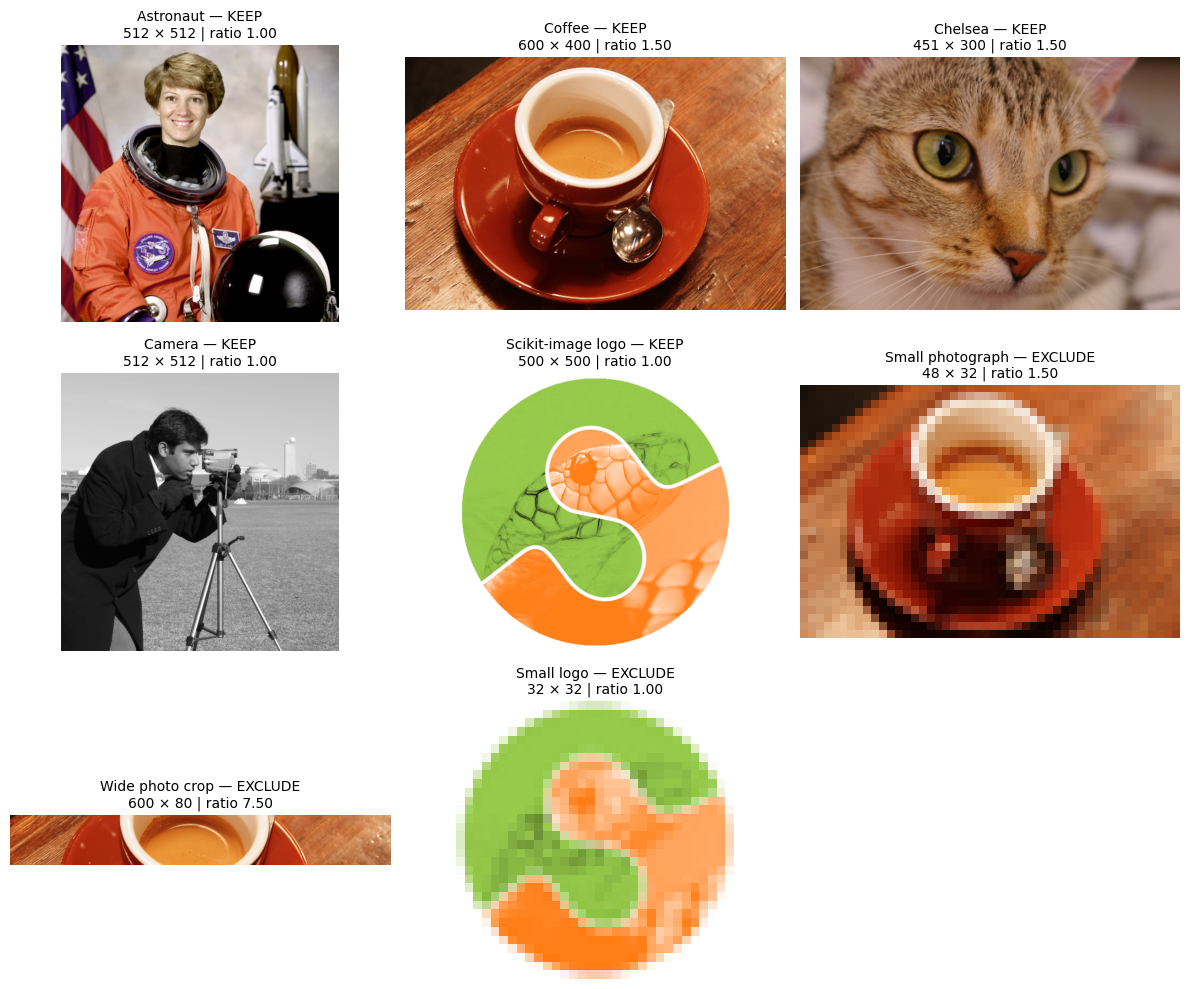

In [19]:
fig, axes = plt.subplots(ceil(len(samples) / 3), 3, figsize=(12, 10))
for ax in axes.flat:
    ax.axis("off")
for ax, sample, row in zip(axes.flat, samples, results):
    ax.imshow(sample["image"], cmap="gray" if sample["image"].mode == "L" else None)
    decision = "KEEP" if row["keep"] else "EXCLUDE"
    ax.set_title(f"{row['name']} — {decision}\n"
                 f"{row['width']} × {row['height']} | ratio {row['aspect_ratio']:.2f}",
                 fontsize=10)
plt.tight_layout()
plt.show()


In [20]:
image_path = None  # Example: Path(r"F:\images\example.jpg")

if image_path is not None:
    with Image.open(image_path) as opened:
        image = opened.copy()
    filtered_image = filter_photo(image, settings)
    print("Size:", image.size)
    print("Decision:", "KEEP" if filtered_image is not None else "EXCLUDE")
    display(image)
else:
    print("Set image_path above to inspect a local image.")


Set image_path above to inspect a local image.
